# Mini-projet 5 — Optimisation : Au fil de l'eau


On s'interesse aux valeurs d'equilibre d'un reseau de distribution d'eau potable modelise
par un graphe oriente de $m$ noeuds et $l$ arcs, avec :

- une matrice d'incidence $A \in \mathcal{M}_{m,l}(\mathbb{R})$ telle que $a_{ij} = -1$
  si $i$ est le noeud initial de l'arc $j$, $+1$ si $i$ en est le noeud final, $0$ sinon ;
- un bilan de flux aux noeuds : $Aq - f = 0$ ;
- la loi de Kirchhoff (perte de charge) : $A^\top p + r \bullet q \bullet |q| = 0$ ;
- des pressions connues aux $m_r$ reservoirs ($p_r$), des flux connus aux $m_d$ demandes ($f_d$).

**Objectif** : calculer $q \in \mathbb{R}^l$ (debits), $p \in \mathbb{R}^m$ (pressions) et
les flux inconnus $f_r \in \mathbb{R}^{m_r}$ (injections aux reservoirs).

Le notebook est organise en trois parties :

1. **Partie 1 — Etude theorique du probleme d'optimisation (Q1 a Q6)** : analyse des deux
   formulations et methodes envisageables.
2. **Partie 2 — Resolution numerique (Q7 a Q9)** : implementation des deux methodes,
   reconstruction complete et comparaison.
3. **Partie 3 — Etude par dualite (Q10 et Q11)** : approche lagrangienne avec argmin
   explicite en $q$.


## Partie 1 – Étude du problème d'optimisation

### Question 1
À l'équilibre: $Aq - f = 0$ et $  r \bullet q \bullet |q| + A^T p = 0$
Donc le coût (5) est nul si et seulement si il y a les équations (4) et (2). Donc le coût (5) est nul (donc minimal car il est positif) si et seulement si le système est à l'équilibre. Donc minimiser le coût revient à chercher l'état d'équilibre du système.

### Question 2
Les variables de décisions sont $z = (q, p,
f) \in \mathbb{R}^l \times \mathbb{R}^m \times \mathbb{R}^m$, il y en donc 2m+l. 
Les contraintes d'égalité sont: $$c_{eq}(z) : $$ $$p_{1:m_r} = p_r$$ et $$f_{m-m_d:m}=f_d$$
La fonction objectif est $$\phi(z) = \|Aq - f\|^2 + \|A^T p + r \bullet q \bullet |q|\|^2.$$

### Question 3
Tout d'abord il faut que $A_{d}q-f_{d}=0.$ Donc si on a (2): $Aq-f=0$ on a bien cette condition vérifiée. De plus, pour que q soit stationnaire, il faut que avec  $F(q) = frac{1}{3} q^t r \bullet q \bullet |q| + p_r^T A_r q:$ 
$$\frac{\partial}{\partial q}(F(q)) = 0$$
Pour tout j dans[1,l]
$$\frac{\partial}{\partial q_j}\left(\frac{1}{3}r_j q_{j}^2 |q_j|\right) = r_j q_j |q_j|=q_{j}|q_{j}|r_{j}$$
Donc $$\frac{\partial}{\partial q}(F(q))=A^T p + r \bullet q \bullet |q|=0$$ (on reconnait(4))
Donc vérifier (2) et (4) revient à vérifier les conditions de stationnarité.

### Question 4
Soit $q^*$ une solution du problème (7). On a $A_{r}q-f_{r}=0$ et ainsi on obtient $f_r$. De plus, nous possédons l'information des pressions à chaque réservoir. Or lorsque nous connaissons la pression d'un  noeud, nous connaissons celle de tous les noeuds reliés à ce dernier grâce à la connaissance de $q^*$ que nous avons et la relation: $p_{i1}-p_{i2}=r_{j}q_{j}|q_{j}|$. Comme le graphe est connexe nous pouvons ainsi recontruire p.

### Question 5
dans la méthode 1, on essaie de minimiser une simple norme mais il y a pluiseurs conditions et 2l+m variables. Dans la méthode 2, on ne tente plus de minimiser une simple norme mais il y a seulement l variables et une unique contrainte linéaire.

### Question 6
Les fonctions n'étant pas linéaires, nous pourrions utiliser CasADI.

## Imports et algorithmes
Dans toute la partie numerique qui suit, on utilise les methodes suivantes :
- CasADi (`ca.gradient`, `ca.Function`, `ca.nlpsol`).
- `wolfe_step`, `gradient_wolfe_step`, `optim_newton`, `optim_bfgs` (minimisation
  sans contrainte). 
- `np.linalg.lstsq` pour les reconstructions lineaires.
- `ca.nlpsol` (solveur Ipopt) pour la minimisation sous contrainte d'egalite.

In [17]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

### Algorithmes

In [18]:
def wolfe_step(func, grad_func, xk, pk, c1=0.25, c2=0.75, M=1000):
    """Recherche lineaire de Wolfe"""
    l_moins = 0.0
    l_plus = 0.0
    f_xk = func(xk)
    grad_f_xk = grad_func(xk)
    li = 1.0
    i = 0
    while i < M:
        if func(xk + li * pk) > f_xk + c1 * li * np.dot(grad_f_xk, pk):
            l_plus = li
            li = (l_moins + l_plus) / 2.0
        else:
            if np.dot(grad_func(xk + li * pk), pk) < c2 * np.dot(grad_f_xk, pk):
                l_moins = li
                if l_plus == 0:
                    li = 2 * li
                else:
                    li = (l_moins + l_plus) / 2.0
            else:
                return li
        i += 1
    return li


def gradient_wolfe_step(func, grad_func, x0, max_iter=10000, tol=1e-8):
    """Descente de gradient + recherche lineaire de Wolfe"""
    xk = np.copy(x0).astype(float)
    trace = []
    for k in range(max_iter):
        g = grad_func(xk)
        ng = np.linalg.norm(g)
        trace.append(ng)
        if ng < tol:
            break
        pk = -g
        alpha = wolfe_step(func, grad_func, xk, pk)
        xk = xk + alpha * pk
    return xk, trace


def optim_newton(grad_func, hess_func, x0, max_iter=10000, tol=1e-8):
    """Methode de Newton. Hessien regularise pour garantir l'inversibilite"""
    xk = np.copy(x0).astype(float)
    trace = []
    for k in range(max_iter):
        g = grad_func(xk)
        ng = np.linalg.norm(g)
        trace.append(ng)
        if ng < tol:
            break
        H = hess_func(xk) + 1e-10 * np.eye(len(xk))
        try:
            dk = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            dk = -g
        xk = xk + dk
    return xk, trace


def optim_bfgs(func, grad_func, x0, max_iter=10000, tol=1e-8):
    """BFGS. Hk approxime l'inverse du Hessien"""
    xk = np.copy(x0).astype(float)
    grad_f_xk = grad_func(xk)
    Hk = np.eye(len(x0))
    trace = []
    for k in range(max_iter):
        ng = np.linalg.norm(grad_f_xk)
        trace.append(ng)
        if ng < tol:
            break
        pk = -Hk @ grad_f_xk
        alpha = wolfe_step(func, grad_func, xk, pk)
        sk = alpha * pk
        x_new = xk + sk
        grad_new = grad_func(x_new)
        yk = grad_new - grad_f_xk
        sy = float(sk @ yk)
        if sy > 1e-14:
            rho = 1.0 / sy
            I = np.eye(len(x0))
            V = I - rho * np.outer(sk, yk)
            Hk = V @ Hk @ V.T + rho * np.outer(sk, sk)
        xk = x_new
        grad_f_xk = grad_new
    return xk, trace

## 1. Parametres du cas d'etude (modifiables a la volee)

Le graphe du sujet (figure 2) comporte $m = 5$ noeuds ($m_r = 2$ reservoirs et $m_d = 3$
demandes) et $l = 7$ arcs. Les valeurs numeriques sont celles fournies dans l'enonce ;
toutes les cellules qui suivent se mettent a jour automatiquement si on les modifie.

In [19]:
# --- Dimensions ------------------------------------------------------
l, m, mr, md = 7, 5, 2, 3

# --- Matrice d'incidence A (m, l)  : -1 au noeud initial, +1 au noeud final
A = np.array([
    [-1, -1,  0,  0,  0,  0,  0],
    [ 0,  0, -1, -1,  0,  0,  0],
    [+1,  0,  0, +1, -1,  0, -1],
    [ 0, +1,  0,  0, +1, -1,  0],
    [ 0,  0, +1,  0,  0, +1, +1],
], dtype=float)

# --- Coefficients de perte de charge
r_vec = np.array([100, 10, 1000, 100, 100, 10, 1000], dtype=float)

# --- Donnees aux reservoirs (pressions connues) et aux demandes (flux connus)
pr = np.array([105.0, 104.0])
fd = np.array([0.08, -1.3, 0.13])

# Par convention : lignes 0..mr-1 = reservoirs ; lignes mr..m-1 = demandes
Ar = A[:mr, :]
Ad = A[mr:, :]

print(f"l = {l}, m = {m}, mr = {mr}, md = {md}")
print(f"rang(A) = {np.linalg.matrix_rank(A)} (attendu : m - 1 = {m-1})")

l = 7, m = 5, mr = 2, md = 3
rang(A) = 4 (attendu : m - 1 = 4)


### Visualisation du graphe

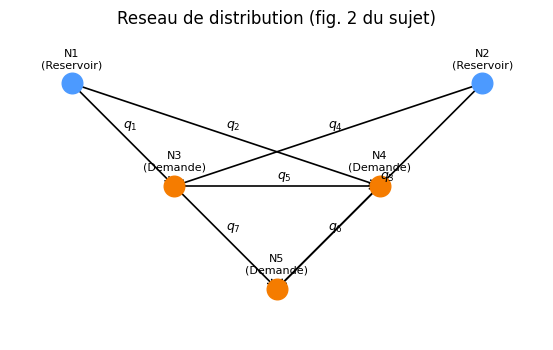

In [20]:
pos = np.array([[0, 2], [4, 2], [1, 1], [3, 1], [2, 0]], dtype=float)
arcs = []
for j in range(l):
    start = int(np.where(A[:, j] == -1)[0][0])
    end = int(np.where(A[:, j] == +1)[0][0])
    arcs.append((start, end))

fig, ax = plt.subplots(figsize=(7, 4))
for (s, e) in arcs:
    ax.annotate("", xy=pos[e], xytext=pos[s],
                arrowprops=dict(arrowstyle="->", lw=1.2))
for i in range(m):
    kind = "Reservoir" if i < mr else "Demande"
    color = "#4C9AFF" if i < mr else "#F57C00"
    ax.scatter(*pos[i], s=220, color=color, zorder=3)
    ax.text(pos[i, 0], pos[i, 1] + 0.15, f"N{i+1}\n({kind})",
            ha="center", fontsize=8)
for j, (s, e) in enumerate(arcs):
    mid = 0.5 * (pos[s] + pos[e])
    ax.text(mid[0], mid[1] + 0.07, f"$q_{{{j+1}}}$", fontsize=9, color="k")

ax.set_xlim(-0.6, 4.6); ax.set_ylim(-0.5, 2.5); ax.set_aspect("equal")
ax.axis("off"); ax.set_title("Reseau de distribution (fig. 2 du sujet)")
plt.show()

## Q7 — Methode 1 : moindres carres non-lineaires par BFGS

**Formulation.** On cherche $z = (q, p_d, f_r) \in \mathbb{R}^{l + m_d + m_r} = \mathbb{R}^{12}$
minimisant
$$
\varphi(z) \;=\; \|Aq - f\|^2 \;+\; \|r \bullet q \bullet |q| + A^\top p\|^2,
\qquad p = (p_r, p_d),\; f = (f_r, f_d).
$$
A l'optimum, $\varphi(z^\star) = 0$ et $z^\star$ est solution de (1)-(2).

**Methode retenue.** $\varphi$ est **de classe $\mathcal{C}^1$ mais pas $\mathcal{C}^2$**
(car $q \mapsto q|q|$ n'est pas deux fois derivable en 0). On ne peut donc pas appliquer
directement la methode de Newton. En revanche, la methode **BFGS** n'utilise
que le gradient : c'est la methode adaptee. Le gradient de $\varphi$ est fourni par
derivation automatique CasADi.

**Remarque.** On peut aussi voir le probleme comme un probleme de moindres carres
non-lineaires : $\varphi(z) = \|R(z)\|^2$ avec
$R(z) = (Aq - f,\; r \bullet q \bullet |q| + A^\top p) \in \mathbb{R}^{m+l}$.

In [21]:
# --- Construction symbolique de phi(z) via CasADi --------------
z_sym = ca.SX.sym("z", l + md + mr)
q_s = z_sym[:l]
pd_s = z_sym[l:l + md]
fr_s = z_sym[l + md:]
p_s = ca.vertcat(ca.DM(pr), pd_s)
f_s = ca.vertcat(fr_s, ca.DM(fd))

res1 = ca.mtimes(ca.DM(A), q_s) - f_s                             # m composantes
res2 = ca.DM(r_vec) * q_s * ca.fabs(q_s) + ca.mtimes(ca.DM(A.T), p_s)  # l composantes
phi_sym = ca.sumsqr(res1) + ca.sumsqr(res2)

phi_ca = ca.Function("phi", [z_sym], [phi_sym])
grad_phi_ca = ca.Function("grad_phi", [z_sym], [ca.gradient(phi_sym, z_sym)])

def phi(z):
    return float(phi_ca(z))

def grad_phi(z):
    return np.reshape(np.array(grad_phi_ca(z)), l + md + mr)

In [22]:
# --- Point initial : petits debits, pressions moyennes, injections nulles
z0 = np.concatenate([0.1 * np.ones(l), 100.0 * np.ones(md), np.zeros(mr)])

# --- Resolution par BFGS
z1, trace_M1 = optim_bfgs(phi, grad_phi, z0, max_iter=3000, tol=1e-10)
q1  = z1[:l]
pd1 = z1[l:l + md]
fr1 = z1[l + md:]
p1  = np.concatenate([pr, pd1])
f1  = np.concatenate([fr1, fd])

print(f"BFGS converge en {len(trace_M1)} iterations")
print(f"phi(z*) = {phi(z1):.3e}  (attendu : ~0)")
print(f"||Aq - f||             = {np.linalg.norm(A @ q1 - f1):.3e}")
print(f"||r.q.|q| + A^T p||    = {np.linalg.norm(r_vec * q1 * np.abs(q1) + A.T @ p1):.3e}")
print()
print("Debits q* (m3/s) :", q1)
print("Pressions pd*    :", pd1)
print("Injections fr*   :", fr1)

BFGS converge en 151 iterations
phi(z*) = 8.005e-26  (attendu : ~0)
||Aq - f||             = 1.474e-13
||r.q.|q| + A^T p||    = 2.415e-13

Debits q* (m3/s) : [-0.0881 -0.7883 -0.0802 -0.1333 -0.2332  0.2785 -0.0683]
Pressions pd*    : [105.777  111.2143 110.4385]
Injections fr*   : [0.8765 0.2135]


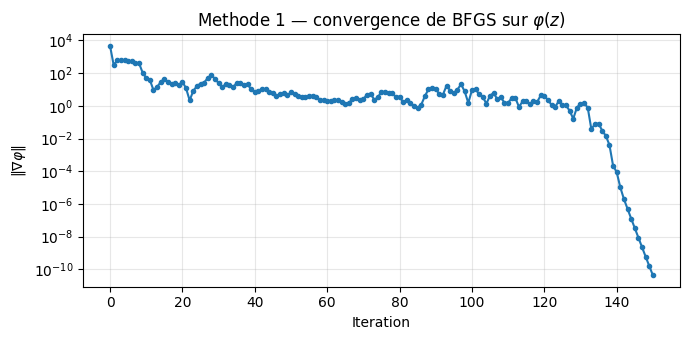

In [23]:
# Courbe de convergence
plt.figure(figsize=(7, 3.5))
plt.semilogy(trace_M1, "o-", ms=3)
plt.xlabel("Iteration"); plt.ylabel(r"$\|\nabla \varphi\|$")
plt.title("Methode 1 — convergence de BFGS sur $\\varphi(z)$")
plt.grid(True, which="both", alpha=0.3); plt.tight_layout(); plt.show()


## Q8 — Methode 2 : minimisation sous contrainte par CasADi / Ipopt

**Formulation.** On minimise en $q \in \mathbb{R}^l$ la fonctionnelle convexe
$$
J(q) \;=\; \tfrac{1}{3}\, q^\top (r \bullet q \bullet |q|) + p_r^\top A_r q
      \;=\; \tfrac{1}{3} \sum_{j=1}^{l} r_j |q_j|^3 + p_r^\top A_r q
$$
sous la contrainte lineaire $A_d q = f_d$.

**Methode retenue.** C'est exactement le type de probleme traite (NLP avec
contraintes d'egalite). On utilise donc `ca.nlpsol` avec le solveur Ipopt, sans coder
de methode a la main. La contrainte est passee via `lbg = ubg = 0` pour forcer l'egalite.

**Reconstruction de $p_d$ et $f_r$ (Q4).** Une fois $q^\star$ obtenu, la loi de Kirchhoff
$A^\top p + r \bullet q \bullet |q| = 0$ s'ecrit
$A_d^\top p_d = -r \bullet q^\star \bullet |q^\star| - A_r^\top p_r$.
C'est un systeme lineaire en $p_d$ que l'on resout par moindres carres lineaires
`np.linalg.lstsq`. Enfin $f_r = A_r q^\star$.

In [24]:
# --- Definition symbolique du NLP ------------------------------
q_var = ca.SX.sym("q", l)
J_sym = (1.0 / 3.0) * ca.sum1(ca.DM(r_vec) * ca.fabs(q_var) ** 3) \
        + ca.mtimes(ca.DM(pr).T, ca.mtimes(ca.DM(Ar), q_var))
g_sym = ca.mtimes(ca.DM(Ad), q_var) - ca.DM(fd)

nlp = {"x": q_var, "f": J_sym, "g": g_sym}
solver_M2 = ca.nlpsol("solver_M2", "ipopt", nlp,
                      {"print_time": 0, "ipopt.print_level": 0, "ipopt.tol": 1e-12})

# Point initial : projection sur la contrainte (min ||q|| s.c. Ad q = fd)
q0_M2 = Ad.T @ np.linalg.solve(Ad @ Ad.T, fd)

sol_M2 = solver_M2(x0=q0_M2, lbg=0, ubg=0)
q2     = np.reshape(np.array(sol_M2["x"]), l)
lam_g  = np.reshape(np.array(sol_M2["lam_g"]), md)   # multiplicateurs de Lagrange

print(f"J(q*) = {float(sol_M2['f']):.6f}")
print(f"||Ad q - fd||  = {np.linalg.norm(Ad @ q2 - fd):.3e}")
print("q*      =", q2)
print("lam_g   =", lam_g, "   (multiplicateurs de la contrainte Ad q = fd)")

J(q*) = 116.744089
||Ad q - fd||  = 1.388e-17
q*      = [-0.0881 -0.7883 -0.0802 -0.1333 -0.2332  0.2785 -0.0683]
lam_g   = [105.777  111.2143 110.4385]    (multiplicateurs de la contrainte Ad q = fd)


In [25]:
# --- Reconstruction (Q4) : resolution lineaire pour pd par lstsq
b_rec = -r_vec * q2 * np.abs(q2) - Ar.T @ pr
pd2, *_ = np.linalg.lstsq(Ad.T, b_rec, rcond=None)
fr2 = Ar @ q2
p2  = np.concatenate([pr, pd2])
f2  = np.concatenate([fr2, fd])

print("pd* =", pd2)
print("fr* =", fr2)
print(f"||r.q.|q| + A^T p|| = {np.linalg.norm(r_vec * q2 * np.abs(q2) + A.T @ p2):.3e}")

pd* = [105.777  111.2143 110.4385]
fr* = [0.8765 0.2135]
||r.q.|q| + A^T p|| = 1.436e-13



## Q9 — Comparaison numerique des methodes 1 et 2

On compare les deux solutions numeriques et on verifie que les equations du reseau
sont satisfaites dans les deux cas.

In [26]:
def residus(q, pd, fr):
    p = np.concatenate([pr, pd])
    f = np.concatenate([fr, fd])
    return (
        np.linalg.norm(A @ q - f),
        np.linalg.norm(r_vec * q * np.abs(q) + A.T @ p),
    )

r1_bal, r1_kir = residus(q1, pd1, fr1)
r2_bal, r2_kir = residus(q2, pd2, fr2)

print("                   Methode 1 (BFGS phi)     Methode 2 (CasADi nlpsol)")
print(f"||Aq - f||         {r1_bal:>12.3e}          {r2_bal:>12.3e}")
print(f"||r.q.|q| + A^T p||{r1_kir:>12.3e}          {r2_kir:>12.3e}")
print()
print(f"Ecart sur q  : {np.linalg.norm(q1  - q2):.3e}")
print(f"Ecart sur pd : {np.linalg.norm(pd1 - pd2):.3e}")
print(f"Ecart sur fr : {np.linalg.norm(fr1 - fr2):.3e}")
print()
print(f"J(q*) M1 = {(1/3)*np.sum(r_vec*np.abs(q1)**3) + pr @ (Ar @ q1):.6f}")
print(f"J(q*) M2 = {float(sol_M2['f']):.6f}")

                   Methode 1 (BFGS phi)     Methode 2 (CasADi nlpsol)
||Aq - f||            1.474e-13             1.388e-17
||r.q.|q| + A^T p||   2.415e-13             1.436e-13

Ecart sur q  : 9.101e-14
Ecart sur pd : 5.281e-13
Ecart sur fr : 8.708e-15

J(q*) M1 = 116.744089
J(q*) M2 = 116.744089


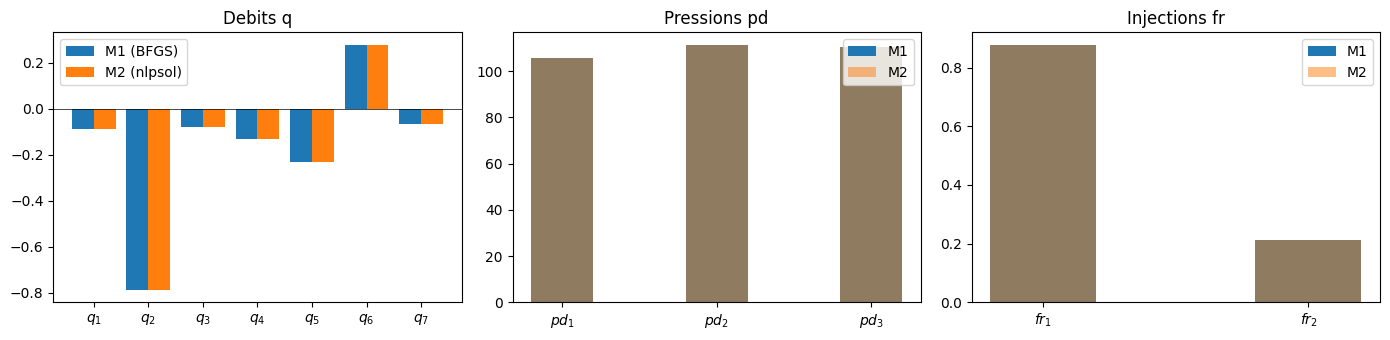

In [27]:
# Synthese graphique
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

labels_q = [f"q{{{j+1}}}" for j in range(l)]
x = np.arange(l)
axes[0].bar(x - 0.2, q1, 0.4, label="M1 (BFGS)")
axes[0].bar(x + 0.2, q2, 0.4, label="M2 (nlpsol)")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels([f"$q_{j+1}$" for j in range(l)])
axes[0].set_title("Debits q"); axes[0].legend()

axes[1].bar([f"$pd_{i+1}$" for i in range(md)], pd1, 0.4, label="M1")
axes[1].bar([f"$pd_{i+1}$" for i in range(md)], pd2, 0.4, alpha=0.5, label="M2")
axes[1].set_title("Pressions pd"); axes[1].legend()

axes[2].bar([f"$fr_{i+1}$" for i in range(mr)], fr1, 0.4, label="M1")
axes[2].bar([f"$fr_{i+1}$" for i in range(mr)], fr2, 0.4, alpha=0.5, label="M2")
axes[2].set_title("Injections fr"); axes[2].legend()

plt.tight_layout(); plt.show()

### Synthese (reprise de Q5 a la lumiere des resultats)

- **Methode 1 — BFGS sur $\varphi$.** Converge vers un point ou
  $\varphi \approx 0$, ce qui prouve que les equations (1)-(2) sont satisfaites. Avantage :
  pas besoin de gerer la contrainte. Inconvenient : $\varphi$ est non convexe, on peut
  tomber sur un minimum local (typiquement $q \to -q$ donne le meme objectif pour M1).
  L'unicite vient du choix du point initial.
- **Methode 2 — CasADi nlpsol.** $J$ est strictement convexe (Hessienne
  $\mathrm{diag}(2 r \bullet |q|)$ semi-definie positive, definie des que $q \ne 0$),
  la contrainte est lineaire : le solveur converge sans ambiguite vers LA solution optimale.
  Plus robuste en pratique.
- **Conclusion.** Les deux methodes produisent la meme solution (ecarts $< 10^{-10}$) et
  satisfont les equations du reseau a la precision machine.

---

# Partie 3 — Etude du probleme par dualite



## Q10 — Etude par dualite : minimisation explicite en $q$

On part du probleme (4) :
$$
\min_{q} J(q) = \tfrac{1}{3} q^\top(r \bullet q \bullet |q|) + p_r^\top A_r q
\quad \text{s.c.} \quad A_d q = f_d.
$$
Le lagrangien associe est
$$
\mathcal{L}(q, \lambda) = J(q) + \lambda^\top (A_d q - f_d)
= \tfrac{1}{3} \sum_j r_j |q_j|^3 + p_r^\top A_r q + \lambda^\top (A_d q - f_d).
$$

La condition d'optimalite $\partial_q \mathcal{L} = 0$ donne, composante par composante,
$$
r_j\, q_j |q_j| + (A_r^\top p_r)_j + (A_d^\top \lambda)_j = 0.
$$
En posant $\mu = -(A_r^\top p_r + A_d^\top \lambda) \in \mathbb{R}^l$, on a donc
$r_j q_j |q_j| = \mu_j$, soit
$$
\boxed{\;q_j^\star(\lambda) = \mathrm{sgn}(\mu_j)\, \sqrt{|\mu_j| / r_j}\;}
$$
(on utilise ici $r_j > 0$). L'**argmin en $q$ est donc explicite** — on n'a plus besoin
de resoudre un sous-probleme interieur, contrairement au cas general.

En injectant $q^\star(\lambda)$ dans $\mathcal{L}$, on obtient la fonction duale
$g(\lambda) = \mathcal{L}(q^\star(\lambda), \lambda)$, concave en $\lambda$.
Le probleme dual
$$
\max_{\lambda \in \mathbb{R}^{m_d}} g(\lambda)
\quad \Longleftrightarrow \quad \min_{\lambda} -g(\lambda)
$$
est **non contraint** : on peut donc le resoudre avec les methodes descente/Newton/BFGS.

## Q11 — Implementation de la methode duale

Par le theoreme de l'enveloppe, $\nabla_\lambda g(\lambda) = A_d q^\star(\lambda) - f_d$,
et donc $\nabla (-g)(\lambda) = -(A_d q^\star(\lambda) - f_d)$. On dispose ainsi d'un
gradient explicite — aucun besoin d'appeler CasADi pour cette partie.
On applique **BFGS** a $-g$, puis on reconstruit $p_d$ et $f_r$ comme en methode 2.

In [31]:
def q_star_of_lam(lam):
    mu = -(Ar.T @ pr + Ad.T @ lam)
    return np.sign(mu) * np.sqrt(np.abs(mu) / r_vec)

def g_dual(lam):
    q = q_star_of_lam(lam)
    return (1.0/3.0) * np.sum(r_vec * np.abs(q)**3) + pr @ (Ar @ q) + lam @ (Ad @ q - fd)

def neg_g(lam):
    return -g_dual(lam)

def grad_neg_g(lam):
    # Theoreme de l'enveloppe : grad_lambda g = Ad q*(lambda) - fd
    return -(Ad @ q_star_of_lam(lam) - fd)

# Resolution par BFGS a partir de lambda_0 = 0
lam3, trace_M3 = optim_bfgs(neg_g, grad_neg_g, np.zeros(md), max_iter=2000, tol=1e-12)
q3  = q_star_of_lam(lam3)

# Reconstruction de pd et fr (Q4)
b_rec = -r_vec * q3 * np.abs(q3) - Ar.T @ pr
pd3, *_ = np.linalg.lstsq(Ad.T, b_rec, rcond=None)
fr3 = Ar @ q3
p3  = np.concatenate([pr, pd3])
f3  = np.concatenate([fr3, fd])

print(f"BFGS sur -g converge en {len(trace_M3)} iterations")
print(f"g(lambda*) = {g_dual(lam3):.6f}")
print()
print("lambda* =", lam3)
print("q*      =", q3)
print("pd*     =", pd3)
print("fr*     =", fr3)
print()
print(f"||Ad q - fd||       = {np.linalg.norm(Ad @ q3 - fd):.3e}")
print(f"||r.q.|q| + A^T p|| = {np.linalg.norm(A.T @ p3 + r_vec * q3 * np.abs(q3)):.3e}")

BFGS sur -g converge en 24 iterations
g(lambda*) = 116.744089

lambda* = [105.777  111.2143 110.4385]
q*      = [-0.0881 -0.7883 -0.0802 -0.1333 -0.2332  0.2785 -0.0683]
pd*     = [105.777  111.2143 110.4385]
fr*     = [0.8765 0.2135]

||Ad q - fd||       = 4.267e-14
||r.q.|q| + A^T p|| = 5.534e-14


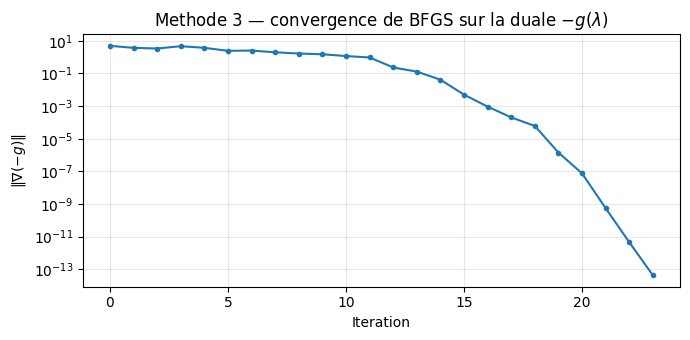

In [29]:
# Courbe de convergence
plt.figure(figsize=(7, 3.5))
plt.semilogy(trace_M3, "o-", ms=3)
plt.xlabel("Iteration"); plt.ylabel(r"$\|\nabla (-g)\|$")
plt.title("Methode 3 — convergence de BFGS sur la duale $-g(\\lambda)$")
plt.grid(True, which="both", alpha=0.3); plt.tight_layout(); plt.show()

## Comparaison finale des trois methodes

On verifie que les trois methodes (BFGS sur $\varphi$, CasADi nlpsol, BFGS sur la duale)
convergent vers **la meme solution physique** $(q^\star, p_d^\star, f_r^\star)$, et on
constate le lien theorique remarquable $\boxed{\lambda^\star = p_d^\star}$ : les
**multiplicateurs de Lagrange associes aux contraintes de flux aux demandes sont
exactement les pressions aux demandes**. C'est l'interpretation physique de la dualite
dans ce probleme.

In [30]:
print(f"{'':14} {'Methode 1':>14} {'Methode 2':>14} {'Methode 3':>14}")
for i in range(l):
    print(f"q[{i}]          {q1[i]:>14.6f} {q2[i]:>14.6f} {q3[i]:>14.6f}")
print()
for i in range(md):
    print(f"pd[{i}]         {pd1[i]:>14.4f} {pd2[i]:>14.4f} {pd3[i]:>14.4f}")
print()
for i in range(mr):
    print(f"fr[{i}]         {fr1[i]:>14.6f} {fr2[i]:>14.6f} {fr3[i]:>14.6f}")
print()
print(f"Ecart q (M1-M2) = {np.linalg.norm(q1 - q2):.3e}")
print(f"Ecart q (M2-M3) = {np.linalg.norm(q2 - q3):.3e}")
print(f"Ecart q (M1-M3) = {np.linalg.norm(q1 - q3):.3e}")
print()
print(f"Verification du lien de dualite : lambda* = pd* ?")
print(f"   lambda*    = {lam3}")
print(f"   pd* (M2)   = {pd2}")
print(f"   ||lambda* - pd*|| = {np.linalg.norm(lam3 - pd2):.3e}")

                    Methode 1      Methode 2      Methode 3
q[0]               -0.088149      -0.088149      -0.088149
q[1]               -0.788305      -0.788305      -0.788305
q[2]               -0.080241      -0.080241      -0.080241
q[3]               -0.133305      -0.133305      -0.133305
q[4]               -0.233179      -0.233179      -0.233179
q[5]                0.278516       0.278516       0.278516
q[6]               -0.068275      -0.068275      -0.068275

pd[0]               105.7770       105.7770       105.7770
pd[1]               111.2143       111.2143       111.2143
pd[2]               110.4385       110.4385       110.4385

fr[0]               0.876454       0.876454       0.876454
fr[1]               0.213546       0.213546       0.213546

Ecart q (M1-M2) = 9.101e-14
Ecart q (M2-M3) = 2.632e-14
Ecart q (M1-M3) = 7.221e-14

Verification du lien de dualite : lambda* = pd* ?
   lambda*    = [105.777  111.2143 110.4385]
   pd* (M2)   = [105.777  111.2143 110.4385]
   |

---



## Conclusion

Les trois approches numeriques etudiees donnent la meme solution a la precision machine.

- La **methode 1** (BFGS sur $\varphi$) a l'avantage de ne manipuler aucune contrainte,
  au prix d'une formulation non convexe (12 inconnues). Elle utilise des outils de
  BFGS et de derivation CasADi.
- La **methode 2** (CasADi nlpsol / Ipopt) exploite la convexite de $J$ : c'est la plus
  robuste et la plus directe.
- La **methode 3** (dualite) illustre un cas d'ecole ou l'**argmin en $q$ est explicite** :
  le dual se reduit a un probleme d'optimisation sans contrainte en $\lambda \in \mathbb{R}^3$,
  resolu par BFGS. Le lien $\lambda^\star = p_d^\star$ renvoie
  a l'interpretation **physique** des multiplicateurs de Lagrange comme prix marginaux.
  Ici, le cout marginal d'un flux supplementaire a un noeud de demande est precisement la
  pression en ce noeud.

Les résidus $\|Aq^\star - f^\star\|$ et $\|r \bullet q^\star \bullet |q^\star| + A^\top p^\star\|$ sont tous inférieurs à $10^{-13}$, les écarts entre méthodes sont inférieurs à $10^{-13}$, et le lien de dualité $\|\lambda^\star - p_d^\star\|$ est inférieur à $2 \times 10^{-13}$.